In [91]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

RANDOM_STATE = 568

# Preprocessing

In [92]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess the dataset by dropping unnecessary columns and handling missing values.

    Args:
        df (pd.DataFrame): The input DataFrame to preprocess.

    Returns:
        pd.DataFrame: The preprocessed DataFrame.
    """
    df.drop(columns=['Sequence_ID'], inplace=True)
    feature_names = df.columns[:-1]

    df = df[df[feature_names].sum(axis=1) > 0]

    df["Virus_Species"] = df["Virus_Species"].apply(lambda x: x.lower())
    
    valid_classes = [
        "orthohantavirus puumalaense", 
        "orthohantavirus dobravaense", \
        "orthohantavirus hantanense",
        "orthohantavirus sinnombreense"
    ]
    df.drop(df[~df["Virus_Species"].isin(valid_classes)].index, axis=0, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df

In [93]:
def drop_low_correlation_features(df: pd.DataFrame, feature_names: list[str], threshold=0.9) -> tuple[pd.DataFrame, list[str]]:
    """
    Identifies highly correlated features and drops one of each pair to remove redundancy.

    Args:
        df (pd.DataFrame): The input DataFrame.
        feature_names (list[str]): The original list of feature column names.
        threshold (float): The correlation coefficient threshold above which a feature is dropped.

    Returns:
        tuple[pd.DataFrame, list[str]]: The DataFrame with dropped features and the updated list of feature names.
    """
    print(f"Original number of features: {len(feature_names)}")
    
    corr_matrix = df[feature_names].corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    
    df_filtered = df.drop(columns=to_drop)
    updated_feature_names = [f for f in feature_names if f not in to_drop]
    
    print(f"Updated number of features: {len(updated_feature_names)}\n")
    return df_filtered, updated_feature_names

In [94]:
from sklearn.model_selection import train_test_split

def split_and_scale_data(df: pd.DataFrame, feature_names: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """
    Splits data into train, validation, and test sets, and scales the features.

    Args:
        df (pd.DataFrame): The input preprocessed DataFrame.
        feature_names (list[str]): List of columns to use as features.

    Returns:
        tuple: Scaled DataFrames (train, val, test) and their corresponding ground truth labels.
    """
    X = df[feature_names]
    y = df["Virus_Species"]
    
    # Stratified split based on species to keep historical context/alignment
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, random_state=RANDOM_STATE, stratify=y_temp)
    
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_names)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

In [95]:
from sklearn.decomposition import PCA

def apply_pca(
    X_train: pd.DataFrame, 
    X_val: pd.DataFrame, 
    X_test: pd.DataFrame, 
    n_components: int | float = 0.95
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Applies Principal Component Analysis (PCA) to reduce the dimensionality of the datasets.

    Args:
        X_train (pd.DataFrame): Scaled training features.
        X_val (pd.DataFrame): Scaled validation features.
        X_test (pd.DataFrame): Scaled test features.
        n_components (int | float): Number of components to keep. If float between 0 and 1, 
                                     it represents the variance ratio to preserve.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: Reduced train, validation, and test DataFrames.
    """
    print(f"Applying PCA (target variance/components: {n_components})...")
    print(f"Shape before PCA: {X_train.shape}")
    
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)
    
    pca_cols = [f"PC_{i+1}" for i in range(X_train_pca.shape[1])]
    
    X_train_reduced = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
    X_val_reduced = pd.DataFrame(X_val_pca, columns=pca_cols, index=X_val.index)
    X_test_reduced = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)
    
    print(f"Shape after PCA: {X_train_reduced.shape}")
    print(f"Total explained variance ratio: {sum(pca.explained_variance_ratio_):.4f}\n")
    
    return X_train_reduced, X_val_reduced, X_test_reduced

# Training the models

In [96]:
MODEL_NAMES = [
    "K-Means (Baseline)",
    "Bisecting K-Means",
    "Agglomerative Clustering",
    "Spectral Clustering",
    "Gaussian Mixture Models (GMM)"
]

N_CLUSTERS = 4  # Aligned with the 4 biological virus species

optimal_models = {}
silhouette_results = {}
val_predictions = {}
test_predictions = {}

def create_clustering_model(model_name: str, params: dict):
    """
    Instantiates a clustering algorithm configuration based on the provided model name.

    Args:
        model_name (str): The name of the clustering algorithm.
        params (dict): Hyperparameters for the model.

    Returns:
        object: An instance of the requested clustering model.
    """
    if model_name == "K-Means (Baseline)":
        return KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, **params)
    elif model_name == "Bisecting K-Means":
        return BisectingKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, **params)
    elif model_name == "Agglomerative Clustering":
        return AgglomerativeClustering(n_clusters=N_CLUSTERS, **params)
    elif model_name == "Spectral Clustering":
        return SpectralClustering(
            n_clusters=N_CLUSTERS, 
            random_state=RANDOM_STATE, 
            eigen_solver="lobpcg",
            assign_labels="discretize",
            n_jobs=-1,
            **params
        )
    elif model_name == "Gaussian Mixture Models (GMM)":
        return GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE, **params)
    return None

In [97]:
import warnings

def train_clustering_models(X_train: pd.DataFrame, X_val: pd.DataFrame):
    """
    Tunes and fits clustering models on training/validation partitions using Silhouette Score.

    Args:
        X_train (pd.DataFrame): Scaled training features.
        X_val (pd.DataFrame): Scaled validation features.
    """
    tuning_grid = {
        "K-Means (Baseline)": {"init": ["k-means++", "random"], "n_init": [x*10 for x in range(1, 6)]},  
        "Bisecting K-Means": {"bisecting_strategy": ["largest_cluster", "biggest_inertia"]},
        "Agglomerative Clustering": {"linkage": ["ward", "complete", "average"]},
        "Spectral Clustering": {"affinity": ["nearest_neighbors", "rbf"], "n_neighbors": [x*10 for x in range(1, 6)]},
        "Gaussian Mixture Models (GMM)": {"covariance_type": ["spherical", "tied", "full"]}
    }

    warnings.filterwarnings("ignore", message="Graph is not fully connected")

    print("\nStarting clustering validation and model optimization...\n")

    for model_name in MODEL_NAMES:
        best_score = -1.0
        best_params = {}
        grid = tuning_grid[model_name]
        
        keys, values = zip(*grid.items())
        experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

        for params in experiments:
            model = create_clustering_model(model_name, params)
            
            if model_name in ["Agglomerative Clustering", "Spectral Clustering"]:
                labels_val = model.fit_predict(X_val)
            else:
                model.fit(X_train)
                labels_val = model.predict(X_val)
            
            score = silhouette_score(X_val, labels_val)
            if score > best_score:
                best_score = score
                best_params = params

        print(f"Optimal {model_name} parameters: {best_params} with Validation Silhouette: {best_score:.4f}")
        
        final_model = create_clustering_model(model_name, best_params)
        if model_name in ["Agglomerative Clustering", "Spectral Clustering"]:
            val_predictions[model_name] = final_model.fit_predict(X_val)
        else:
            final_model.fit(X_train)
            val_predictions[model_name] = final_model.predict(X_val)
            
        optimal_models[model_name] = final_model

In [98]:
def evaluate_clustering_performance(X_test: pd.DataFrame):
    """
    Computes external/internal mathematical assessment metrics on the finalized unseen test set.

    Args:
        X_test (pd.DataFrame): Scaled test dataset features.
    """
    print("\nFinal Evaluation Metrics on Test Set:")
    
    for model_name in MODEL_NAMES:
        model = optimal_models[model_name]
        
        if model_name in ["Agglomerative Clustering", "Spectral Clustering"]:
            labels_test = model.fit_predict(X_test)
        elif model_name == "Gaussian Mixture Models (GMM)":
            labels_test = model.predict(X_test)
        else:
            labels_test = model.predict(X_test)
            
        test_predictions[model_name] = labels_test
        
        sil = silhouette_score(X_test, labels_test)
        db = davies_bouldin_score(X_test, labels_test)
        ch = calinski_harabasz_score(X_test, labels_test)
        
        silhouette_results[model_name] = sil
        
        print(f"\n--- {model_name} ---")
        print(f"Silhouette Score (Higher is better): {sil:.4f}")
        print(f"Davies-Bouldin Index (Lower is better): {db:.4f}")
        print(f"Calinski-Harabasz Score (Higher is better): {ch:.4f}")

In [99]:
def plot_silhouette_results(results: dict):
    """
    Plots a sorted bar chart comparison of Silhouette coefficients across models.

    Args:
        results (dict): Dictionary with model names as keys and Silhouette scores as values.
    """
    sorted_results = sorted(results.items(), key=lambda item: item[1], reverse=True)
    names, values = zip(*sorted_results)

    plt.figure(figsize=(12, 5))
    sns.barplot(
        x=list(names), 
        y=list(values), 
        palette="YlGnBu", 
        hue=list(names), 
        legend=False
    )
    
    plt.title("Test Silhouette Score for Optimized Clustering Frameworks", fontsize=14, pad=15)
    plt.ylabel("Silhouette Score (-1.0 to 1.0)", fontsize=12)
    plt.xlabel("Optimized Clusterers", fontsize=12)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)

    for idx, val in enumerate(values):
        plt.text(idx, val + 0.01 if val >= 0 else val - 0.03, f"{val:.4f}", ha="center", fontweight="bold", fontsize=11)

    plt.tight_layout()
    plt.show()

In [100]:
def plot_tsne_clusters(X_test: pd.DataFrame, predictions: dict):
    """
    Reduces the test feature footprint via t-SNE and projects the predicted structural clusters.

    Args:
        X_test (pd.DataFrame): Scaled test dataset features.
        predictions (dict): Dictionary mapping model names to their predicted cluster arrays.
    """
    print("\nComputing t-SNE projection for cluster visualization...")
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_jobs=-1)
    X_embedded = tsne.fit_transform(X_test)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.ravel()
    
    for idx, model_name in enumerate(MODEL_NAMES):
        ax = axes[idx]
        scatter = ax.scatter(
            X_embedded[:, 0], 
            X_embedded[:, 1], 
            c=predictions[model_name], 
            cmap="YlGnBu", 
            edgecolor="k", 
            alpha=0.7, 
            s=40
        )
        ax.set_title(f"{model_name} Clusters", fontsize=12, fontweight="bold")
        ax.set_xlabel("t-SNE Dimension 1")
        ax.set_ylabel("t-SNE Dimension 2")
        fig.colorbar(scatter, ax=ax, label="Cluster ID")
        
    # Remove the last empty subplot axis frame
    if len(MODEL_NAMES) < len(axes):
        fig.delaxes(axes[-1])
        
    plt.suptitle("Unsupervised Sequence Clustering Topography mapped inside 2D t-SNE Space", fontsize=15, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

In [101]:
def train_and_evaluate(df: pd.DataFrame, feature_names: list[str], should_apply_pca: bool = False):
    """
    Orchestrates data pipeline processing, scaling, unsupervised training, structure evaluation, and spatial charts.

    Args:
        df (pd.DataFrame): Raw structural dataset input.
        feature_names (list[str]): Initial genomic sequence characteristics list.
        should_apply_pca (bool): True if the dimensionality reduction via PCA should be applied before clustering, False otherwise.
    """
    df_cleaned = preprocess_data(df)
    df_filtered, updated_features = drop_low_correlation_features(df_cleaned, feature_names, threshold=0.9)
    X_train, X_val, X_test, _, _, _ = split_and_scale_data(df_filtered, updated_features)

    if should_apply_pca:
        X_train, X_val, X_test = apply_pca(
            X_train, X_val, X_test, n_components=0.95
        )

    train_clustering_models(X_train, X_val)
    evaluate_clustering_performance(X_test)

    plot_silhouette_results(silhouette_results)
    plot_tsne_clusters(X_test, test_predictions)

# All sequences dataset

Original number of features: 77
Updated number of features: 58


Starting clustering validation and model optimization...

Optimal K-Means (Baseline) parameters: {'init': 'k-means++', 'n_init': 10} with Validation Silhouette: 0.6299
Optimal Bisecting K-Means parameters: {'bisecting_strategy': 'largest_cluster'} with Validation Silhouette: 0.1634
Optimal Agglomerative Clustering parameters: {'linkage': 'average'} with Validation Silhouette: 0.6757
Optimal Spectral Clustering parameters: {'affinity': 'rbf', 'n_neighbors': 10} with Validation Silhouette: 0.6121
Optimal Gaussian Mixture Models (GMM) parameters: {'covariance_type': 'tied'} with Validation Silhouette: 0.2305

Final Evaluation Metrics on Test Set:

--- K-Means (Baseline) ---
Silhouette Score (Higher is better): 0.6102
Davies-Bouldin Index (Lower is better): 1.1142
Calinski-Harabasz Score (Higher is better): 139.3591

--- Bisecting K-Means ---
Silhouette Score (Higher is better): 0.1372
Davies-Bouldin Index (Lower is better): 

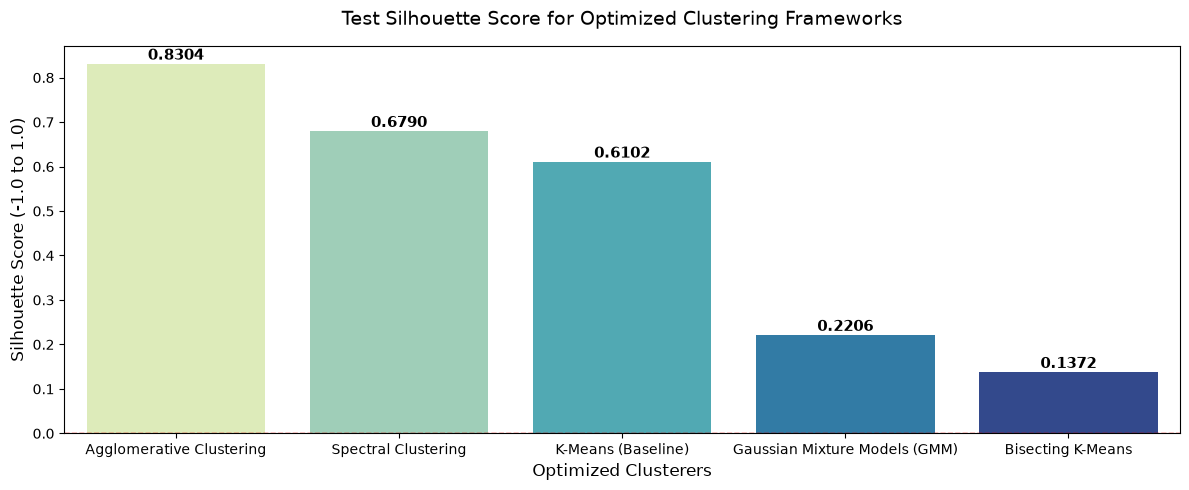


Computing t-SNE projection for cluster visualization...


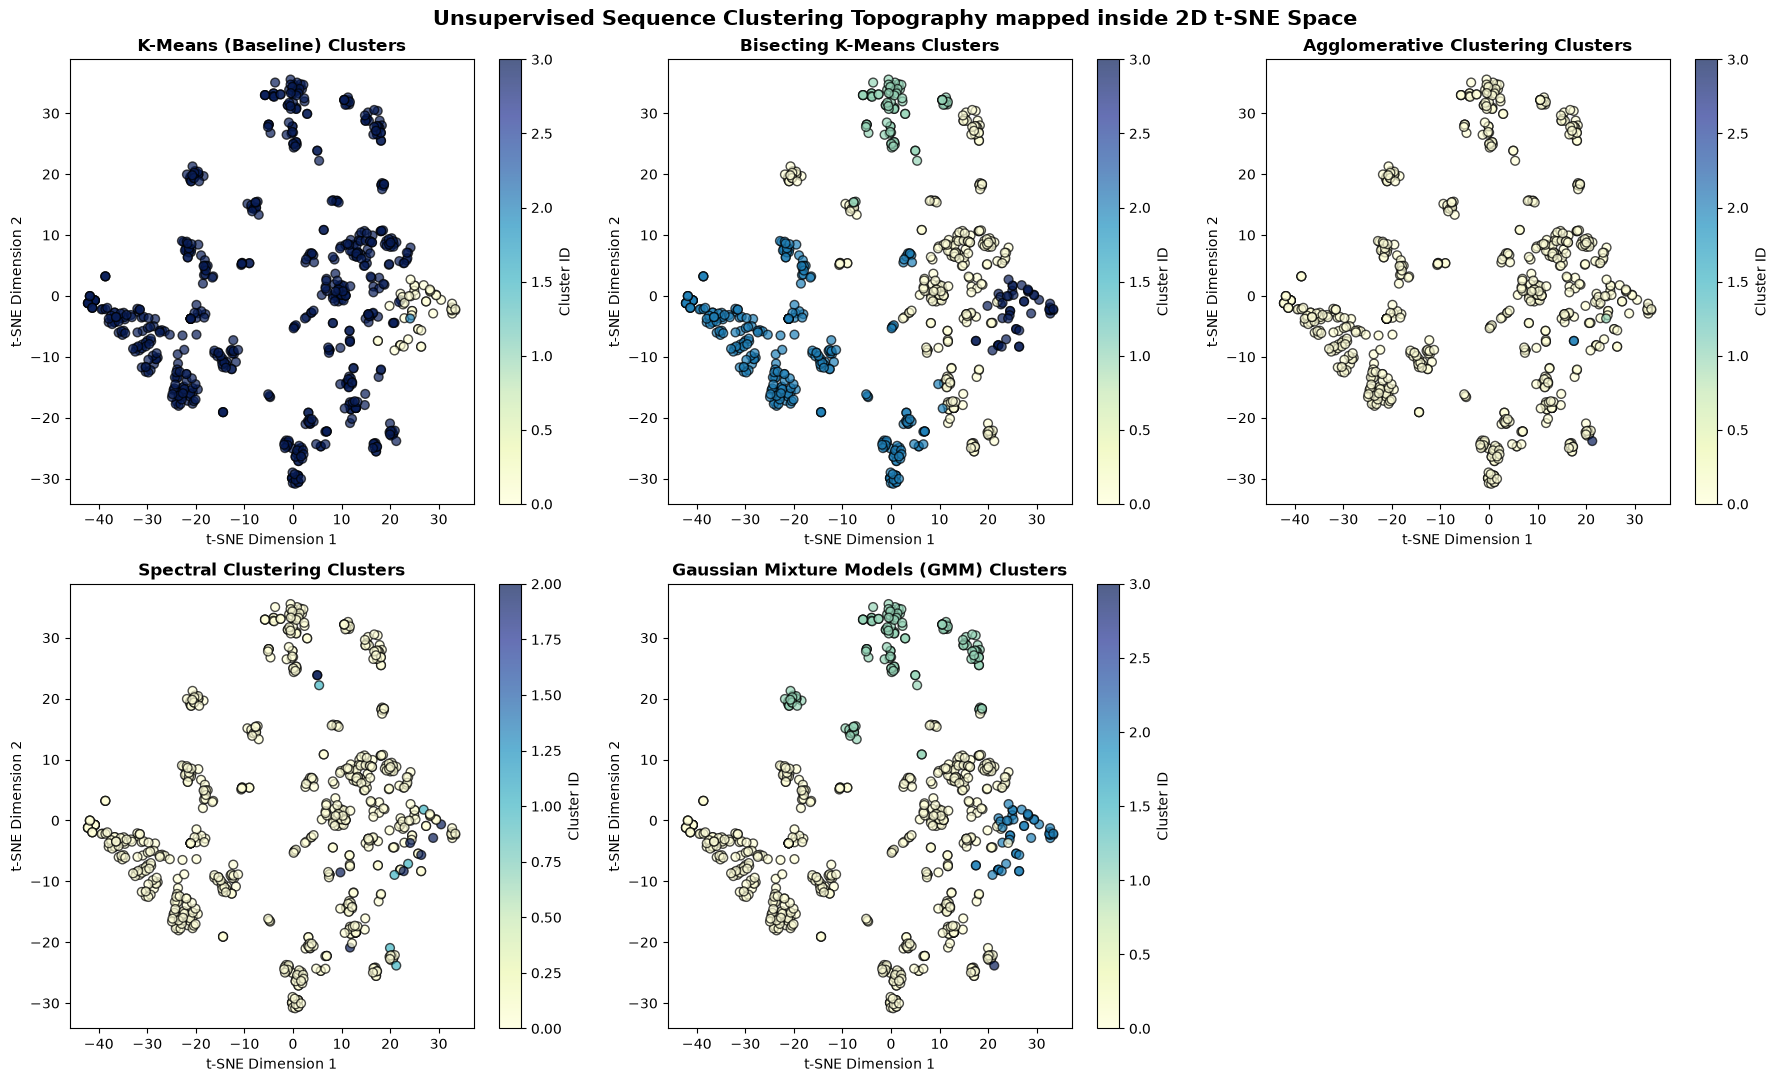

In [102]:
CURRENT_DIR = os.path.dirname(os.path.abspath("__file__"))
ALL_SEQUENCES_DATASET_PATH = os.path.join(CURRENT_DIR, 'data', "dataset_all_sequences.csv")

df_raw = pd.read_csv(ALL_SEQUENCES_DATASET_PATH)
initial_features = list(df_raw.columns[1:-1])
train_and_evaluate(df_raw, initial_features, should_apply_pca=False)

## With PCA

Original number of features: 77
Updated number of features: 58

Applying PCA (target variance/components: 0.95)...
Shape before PCA: (5392, 58)
Shape after PCA: (5392, 31)
Total explained variance ratio: 0.9543


Starting clustering validation and model optimization...

Optimal K-Means (Baseline) parameters: {'init': 'k-means++', 'n_init': 10} with Validation Silhouette: 0.6380
Optimal Bisecting K-Means parameters: {'bisecting_strategy': 'largest_cluster'} with Validation Silhouette: 0.2927
Optimal Agglomerative Clustering parameters: {'linkage': 'average'} with Validation Silhouette: 0.6872
Optimal Spectral Clustering parameters: {'affinity': 'rbf', 'n_neighbors': 10} with Validation Silhouette: 0.6441
Optimal Gaussian Mixture Models (GMM) parameters: {'covariance_type': 'tied'} with Validation Silhouette: 0.5828

Final Evaluation Metrics on Test Set:

--- K-Means (Baseline) ---
Silhouette Score (Higher is better): 0.6142
Davies-Bouldin Index (Lower is better): 1.0751
Calinski-Harabas

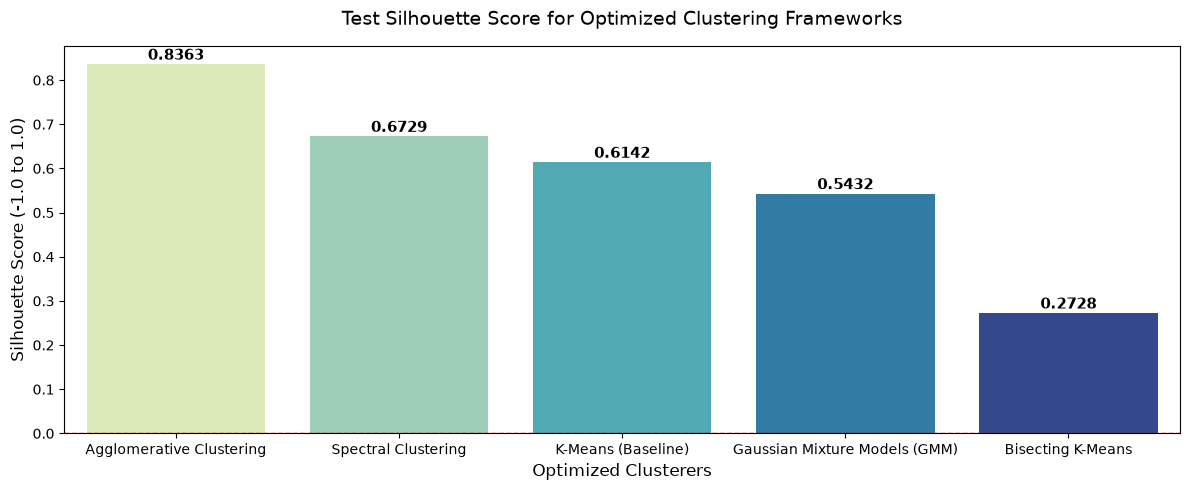


Computing t-SNE projection for cluster visualization...


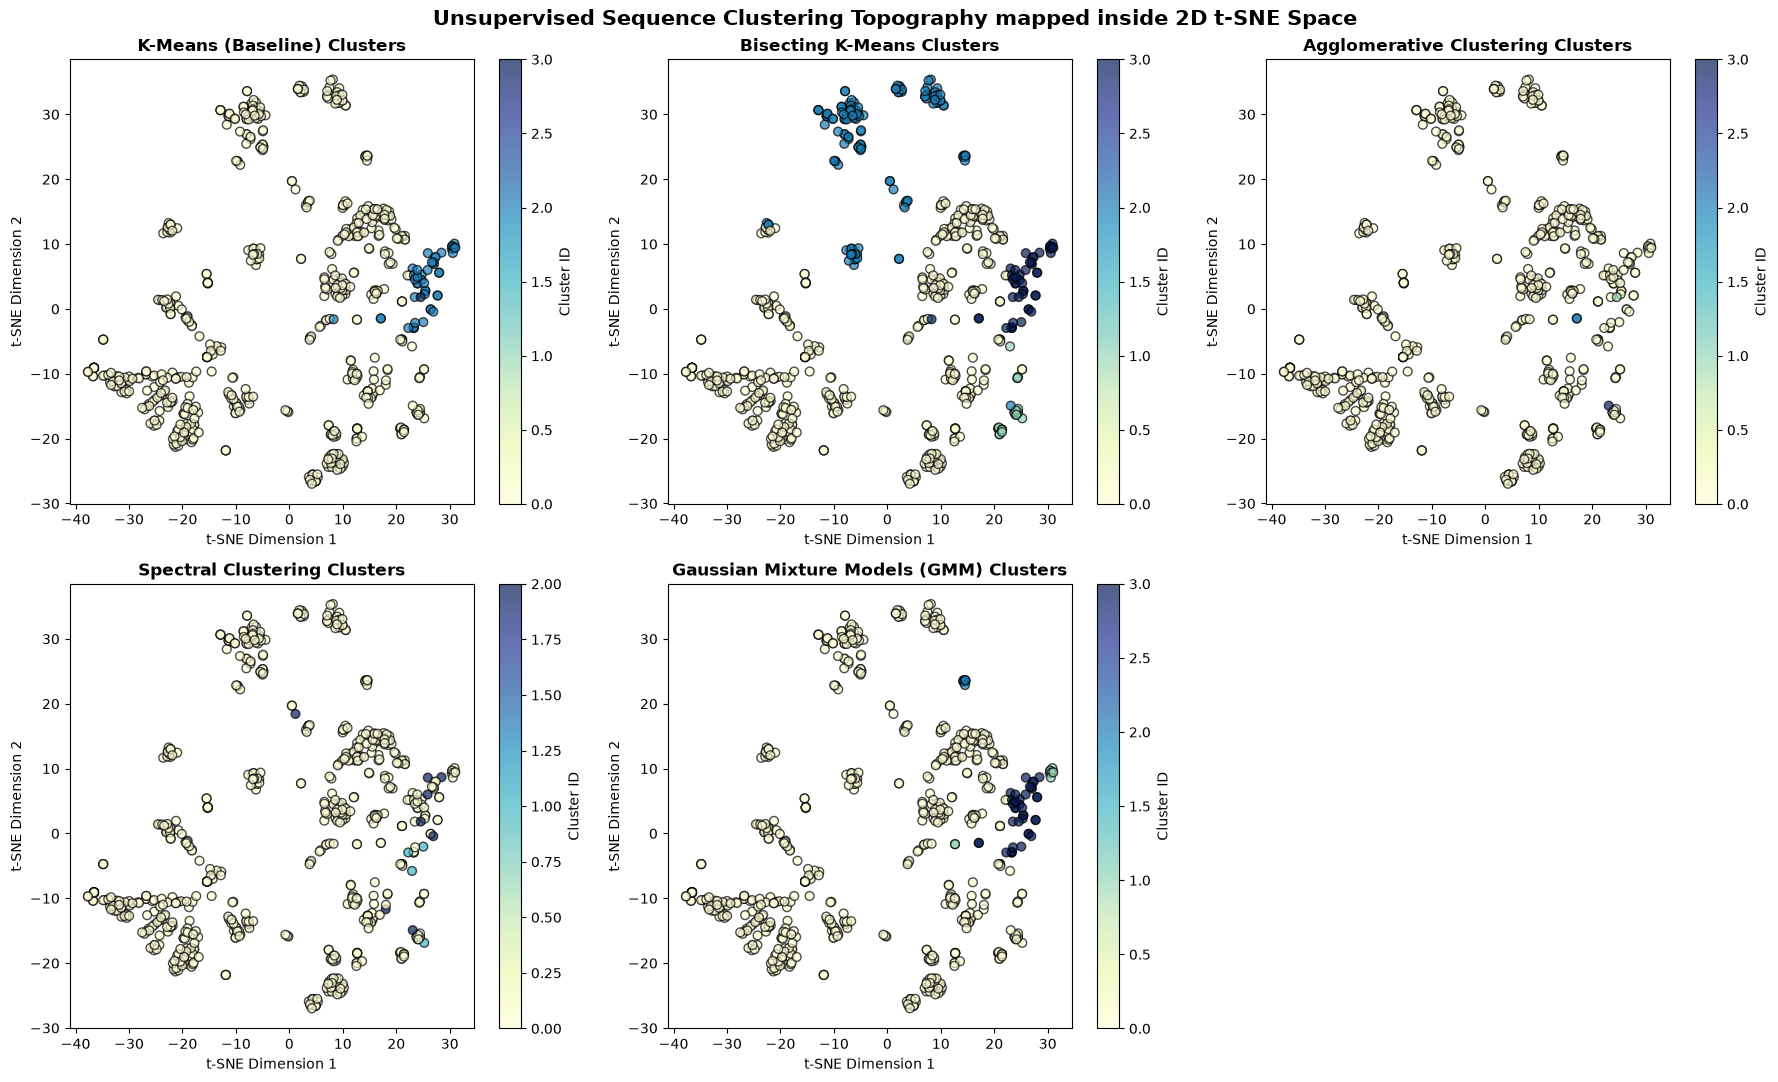

In [103]:
df_raw = pd.read_csv(ALL_SEQUENCES_DATASET_PATH)
initial_features = list(df_raw.columns[1:-1])
train_and_evaluate(df_raw, initial_features, should_apply_pca=True)

# Complete sequences dataset

Original number of features: 77
Updated number of features: 58


Starting clustering validation and model optimization...

Optimal K-Means (Baseline) parameters: {'init': 'k-means++', 'n_init': 10} with Validation Silhouette: 0.6299
Optimal Bisecting K-Means parameters: {'bisecting_strategy': 'largest_cluster'} with Validation Silhouette: 0.1634
Optimal Agglomerative Clustering parameters: {'linkage': 'average'} with Validation Silhouette: 0.6757
Optimal Spectral Clustering parameters: {'affinity': 'rbf', 'n_neighbors': 10} with Validation Silhouette: 0.6121
Optimal Gaussian Mixture Models (GMM) parameters: {'covariance_type': 'tied'} with Validation Silhouette: 0.2305

Final Evaluation Metrics on Test Set:

--- K-Means (Baseline) ---
Silhouette Score (Higher is better): 0.6102
Davies-Bouldin Index (Lower is better): 1.1142
Calinski-Harabasz Score (Higher is better): 139.3591

--- Bisecting K-Means ---
Silhouette Score (Higher is better): 0.1372
Davies-Bouldin Index (Lower is better): 

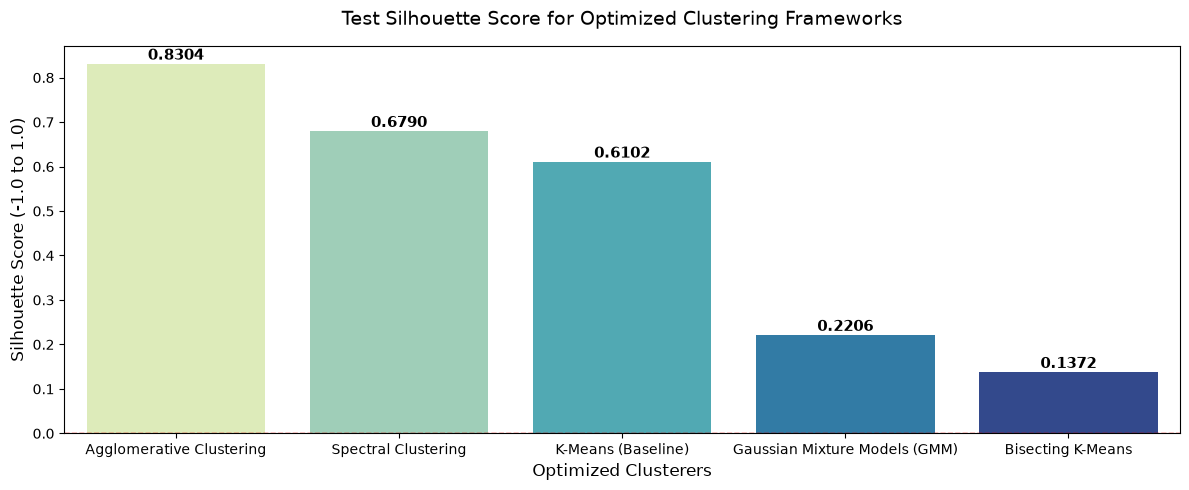


Computing t-SNE projection for cluster visualization...


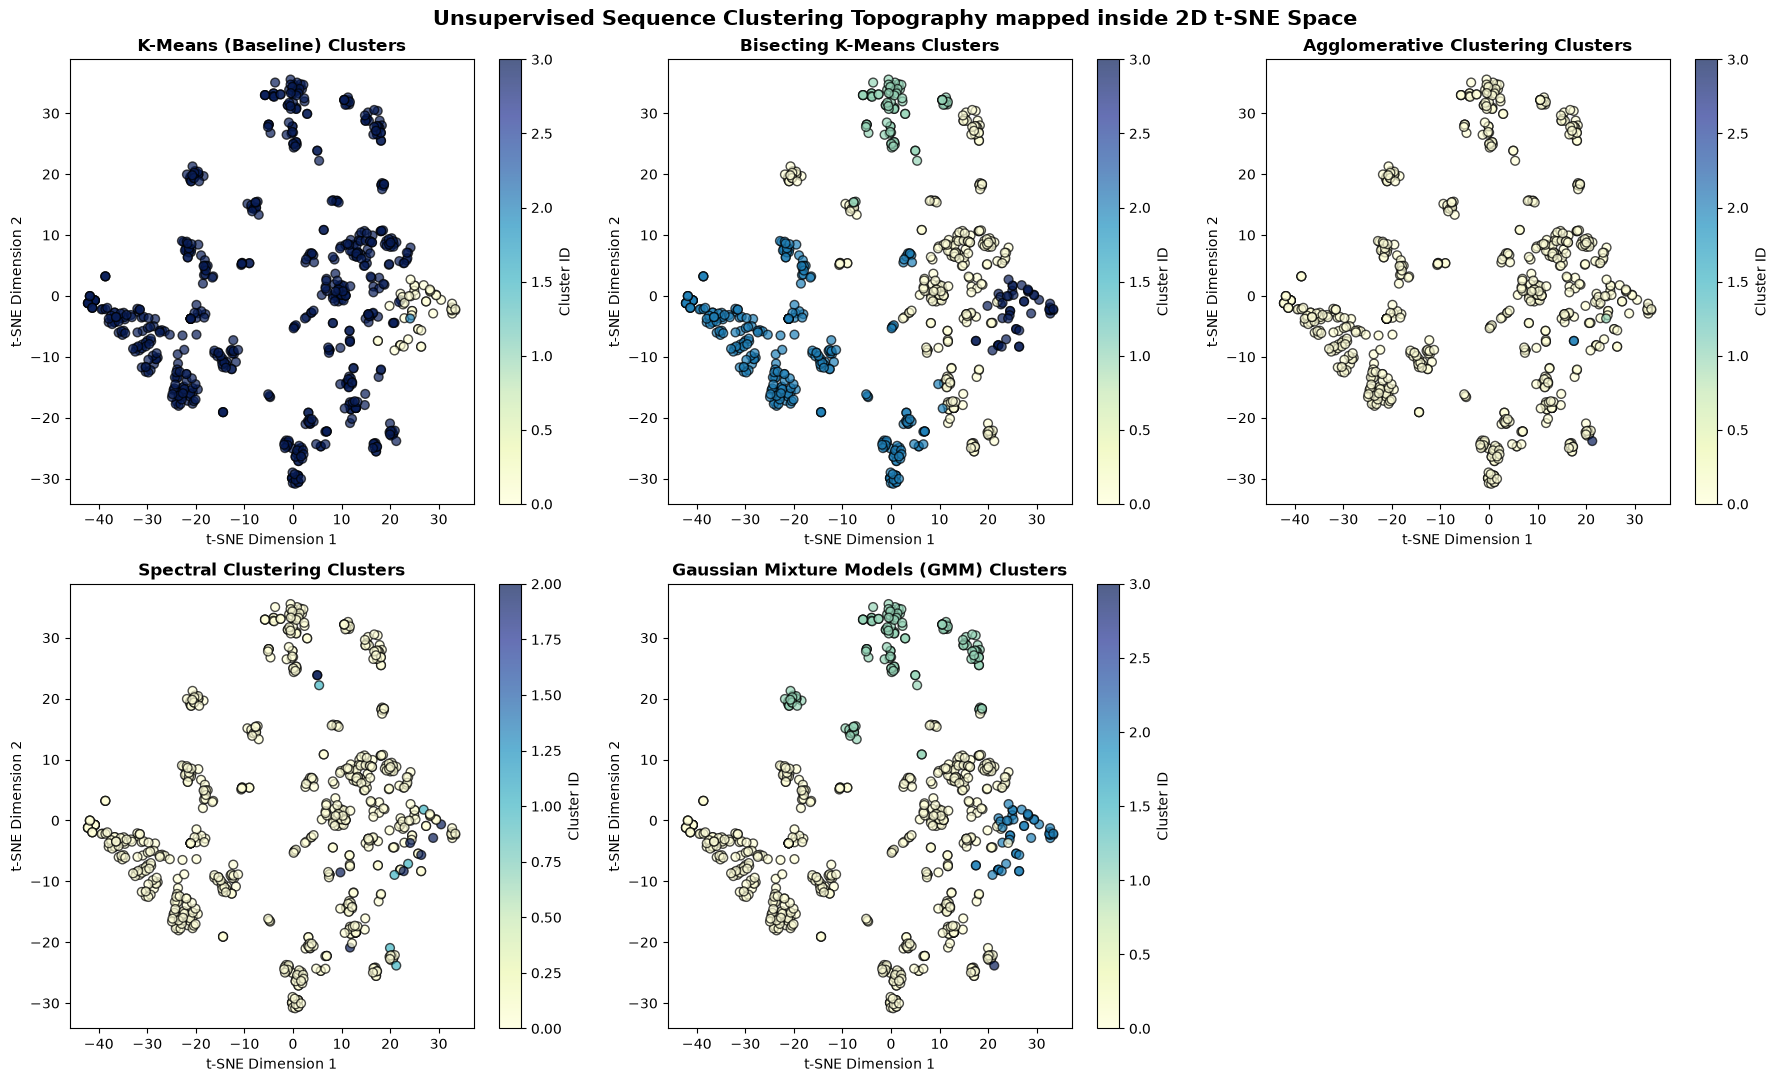

In [104]:
COMPLETE_SEQUENCES_DATASET_PATH = os.path.join(CURRENT_DIR, 'data', "dataset_all_sequences.csv")

df_raw = pd.read_csv(COMPLETE_SEQUENCES_DATASET_PATH)
initial_features = list(df_raw.columns[1:-1])
train_and_evaluate(df_raw, initial_features, should_apply_pca=False)

## With PCA

Original number of features: 77
Updated number of features: 58

Applying PCA (target variance/components: 0.95)...
Shape before PCA: (5392, 58)
Shape after PCA: (5392, 31)
Total explained variance ratio: 0.9543


Starting clustering validation and model optimization...

Optimal K-Means (Baseline) parameters: {'init': 'k-means++', 'n_init': 10} with Validation Silhouette: 0.6380
Optimal Bisecting K-Means parameters: {'bisecting_strategy': 'largest_cluster'} with Validation Silhouette: 0.2927
Optimal Agglomerative Clustering parameters: {'linkage': 'average'} with Validation Silhouette: 0.6872
Optimal Spectral Clustering parameters: {'affinity': 'rbf', 'n_neighbors': 10} with Validation Silhouette: 0.6441
Optimal Gaussian Mixture Models (GMM) parameters: {'covariance_type': 'tied'} with Validation Silhouette: 0.5828

Final Evaluation Metrics on Test Set:

--- K-Means (Baseline) ---
Silhouette Score (Higher is better): 0.6142
Davies-Bouldin Index (Lower is better): 1.0751
Calinski-Harabas

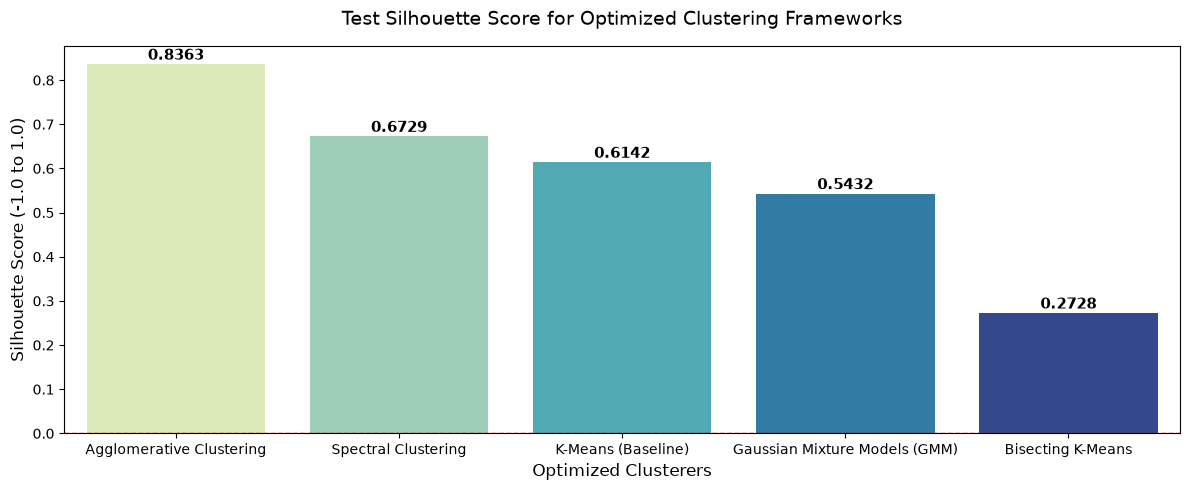


Computing t-SNE projection for cluster visualization...


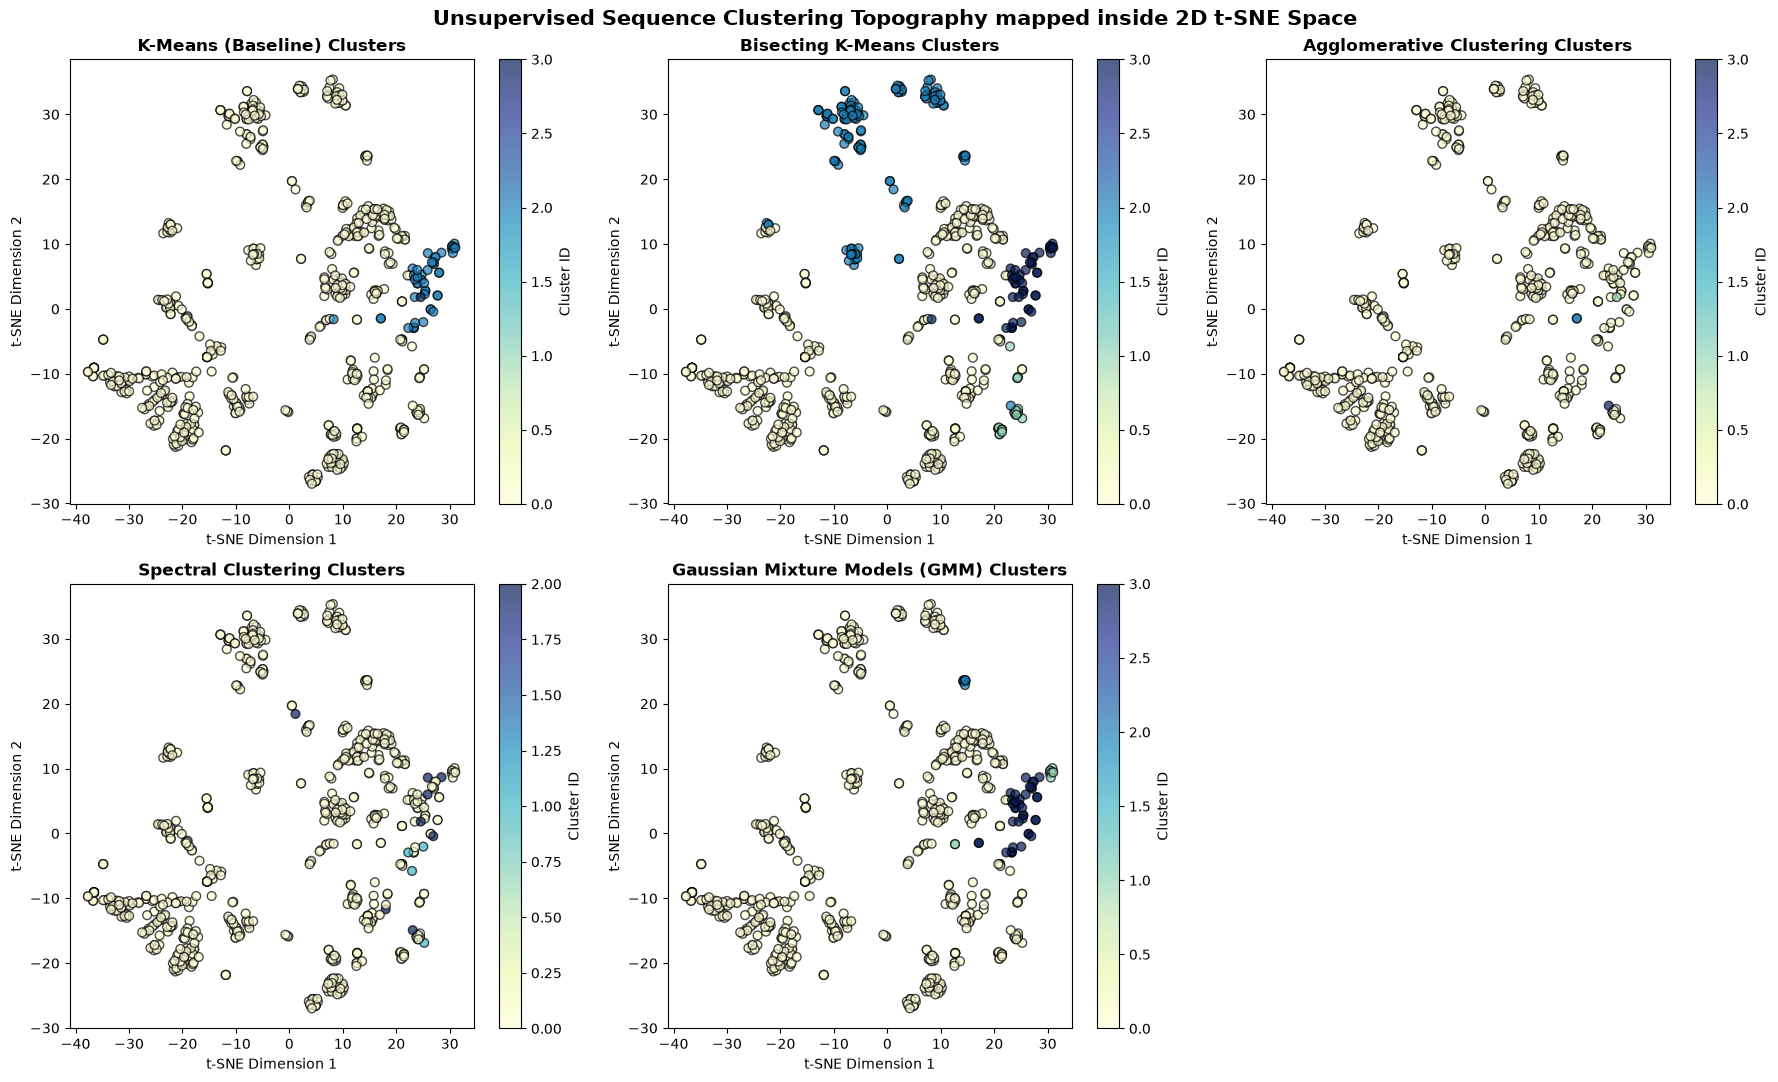

In [105]:
df_raw = pd.read_csv(COMPLETE_SEQUENCES_DATASET_PATH)
initial_features = list(df_raw.columns[1:-1])
train_and_evaluate(df_raw, initial_features, should_apply_pca=True)